# Mutual Fund Analytics - Exploratory Data Analysis

## Objective

The objective of this notebook is to explore the Mutual Fund Analytics dataset, identify trends, detect patterns, and generate business insights using SQL and Python visualizations.

---

### Technologies Used

- Python
- Pandas
- NumPy
- SQLite
- Matplotlib
- Plotly

---

Author: Sathvika G Naik

In [6]:
import sqlite3

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import plotly.express as px

plt.rcParams["figure.figsize"] = (10,6)

In [7]:
DATABASE = "../data/db/bluestock_mf.db"

conn = sqlite3.connect(DATABASE)

print("Database Connected Successfully!")

Database Connected Successfully!


In [8]:
fund_master = pd.read_sql(
    "SELECT * FROM fund_master",
    conn
)

scheme_performance = pd.read_sql(
    "SELECT * FROM scheme_performance",
    conn
)

transactions = pd.read_sql(
    "SELECT * FROM investor_transactions",
    conn
)

nav_history = pd.read_sql(
    "SELECT * FROM nav_history",
    conn
)

print("All tables loaded successfully!")

All tables loaded successfully!


In [9]:
print("Fund Master:", fund_master.shape)

print("Scheme Performance:", scheme_performance.shape)

print("Transactions:", transactions.shape)

print("NAV History:", nav_history.shape)

Fund Master: (40, 15)
Scheme Performance: (40, 19)
Transactions: (32778, 13)
NAV History: (46000, 3)


In [10]:
print("=" * 60)
print("DATASET SHAPES")
print("=" * 60)

print(f"Fund Master           : {fund_master.shape}")
print(f"Scheme Performance    : {scheme_performance.shape}")
print(f"Investor Transactions : {transactions.shape}")
print(f"NAV History           : {nav_history.shape}")

DATASET SHAPES
Fund Master           : (40, 15)
Scheme Performance    : (40, 19)
Investor Transactions : (32778, 13)
NAV History           : (46000, 3)


In [11]:
fund_master.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [12]:
scheme_performance.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [13]:
transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,REDEMPTION,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,LUMPSUM,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [14]:
nav_history.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [15]:
print("=" * 60)
print("MISSING VALUES")
print("=" * 60)

print("\nFund Master")
print(fund_master.isnull().sum())

print("\nScheme Performance")
print(scheme_performance.isnull().sum())

print("\nInvestor Transactions")
print(transactions.isnull().sum())

print("\nNAV History")
print(nav_history.isnull().sum())

MISSING VALUES

Fund Master
amfi_code             0
fund_house            0
scheme_name           0
category              0
sub_category          0
plan                  0
launch_date           0
benchmark             0
expense_ratio_pct     0
exit_load_pct         0
min_sip_amount        0
min_lumpsum_amount    0
fund_manager          0
risk_category         0
sebi_category_code    0
dtype: int64

Scheme Performance
amfi_code             0
scheme_name           0
fund_house            0
category              0
plan                  0
return_1yr_pct        0
return_3yr_pct        0
return_5yr_pct        0
benchmark_3yr_pct     0
alpha                 0
beta                  0
sharpe_ratio          0
sortino_ratio         0
std_dev_ann_pct       0
max_drawdown_pct      0
aum_crore             0
expense_ratio_pct     0
morningstar_rating    0
risk_grade            0
dtype: int64

Investor Transactions
investor_id           0
transaction_date      0
amfi_code             0
transaction_typ

In [16]:
print("=" * 60)
print("FUND MASTER")
print("=" * 60)
fund_master.info()

print("\n")

print("=" * 60)
print("SCHEME PERFORMANCE")
print("=" * 60)
scheme_performance.info()

print("\n")

print("=" * 60)
print("INVESTOR TRANSACTIONS")
print("=" * 60)
transactions.info()

print("\n")

print("=" * 60)
print("NAV HISTORY")
print("=" * 60)
nav_history.info()

FUND MASTER
<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   amfi_code           40 non-null     int64  
 1   fund_house          40 non-null     str    
 2   scheme_name         40 non-null     str    
 3   category            40 non-null     str    
 4   sub_category        40 non-null     str    
 5   plan                40 non-null     str    
 6   launch_date         40 non-null     str    
 7   benchmark           40 non-null     str    
 8   expense_ratio_pct   40 non-null     float64
 9   exit_load_pct       40 non-null     float64
 10  min_sip_amount      40 non-null     int64  
 11  min_lumpsum_amount  40 non-null     int64  
 12  fund_manager        40 non-null     str    
 13  risk_category       40 non-null     str    
 14  sebi_category_code  40 non-null     str    
dtypes: float64(2), int64(3), str(10)
memory usage: 4.8 KB


SC

In [17]:
print("=" * 60)
print("SCHEME PERFORMANCE SUMMARY")
print("=" * 60)

scheme_performance.describe()

SCHEME PERFORMANCE SUMMARY


,amfi_code,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating
count,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.00000,40.000000,40.000000
mean,120247.000000,14.376000,14.089000,14.516750,12.835500,1.253500,0.873250,1.361750,2.082500,14.962500,-19.200250,26091.60000,1.237000,4.250000
std,14534.998667,4.883023,4.617253,4.454021,4.740972,0.447412,0.224846,1.475805,2.203144,6.669282,8.819164,13809.11134,0.386584,0.742484
min,100016.000000,4.260000,5.140000,5.430000,3.960000,0.510000,0.220000,0.800000,1.030000,0.500000,-33.500000,979.00000,0.550000,3.000000
25%,118632.750000,11.735000,12.035000,12.340000,10.690000,0.887500,0.890000,0.865000,1.270000,14.000000,-25.062500,17400.50000,0.787500,4.000000
50%,119551.500000,14.620000,14.205000,14.185000,13.090000,1.205000,0.960000,0.925000,1.445000,14.000000,-20.600000,26713.00000,1.425000,4.000000
75%,120842.250000,16.392500,15.882500,17.585000,14.775000,1.700000,1.000000,0.985000,1.637500,19.000000,-14.255000,38125.00000,1.540000,5.000000
max,149324.000000,24.930000,23.390000,23.800000,22.160000,1.980000,1.040000,7.680000,10.370000,25.000000,-2.230000,49046.00000,1.640000,5.000000


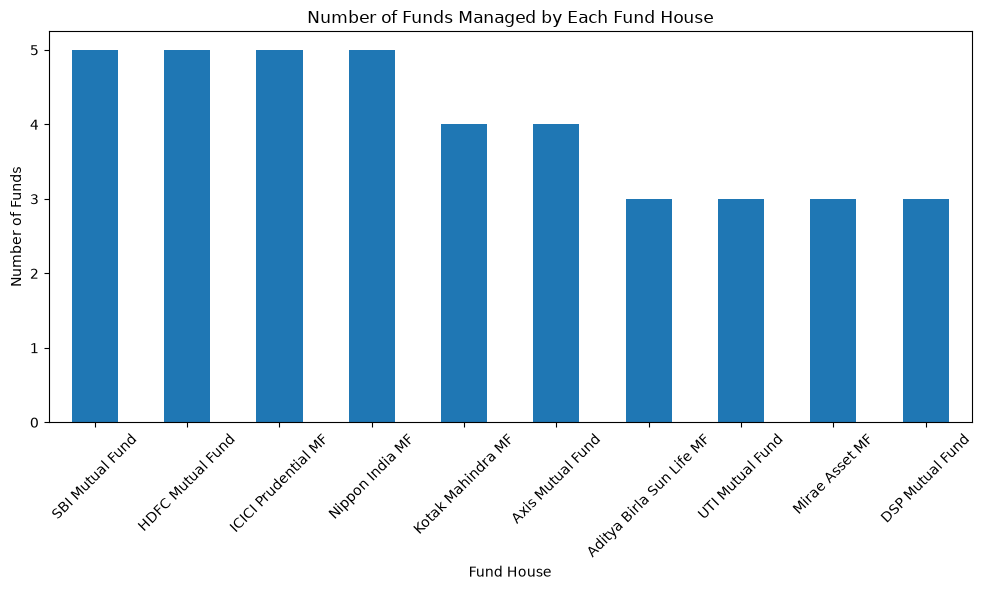

In [18]:
fund_counts = (
    fund_master["fund_house"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

fund_counts.plot(kind="bar")

plt.title("Number of Funds Managed by Each Fund House")

plt.xlabel("Fund House")

plt.ylabel("Number of Funds")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

## Insight

This chart shows the number of mutual fund schemes managed by each fund house. A larger number of schemes indicates greater product diversity, allowing investors to choose from a wider range of investment options.

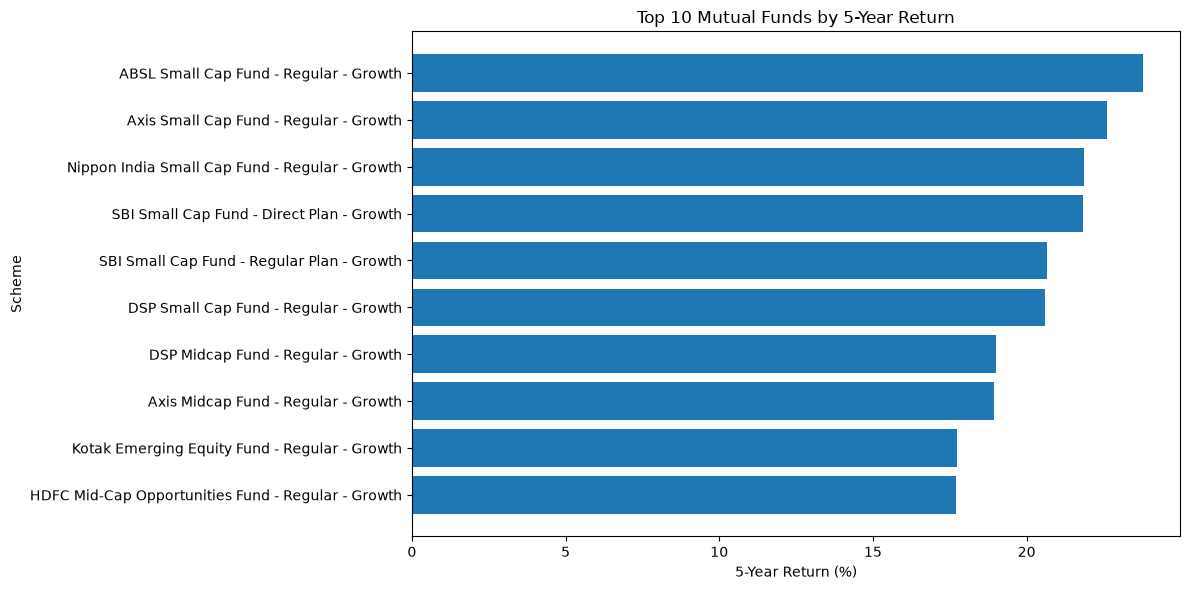

In [19]:
top10 = (
    scheme_performance
    .sort_values("return_5yr_pct", ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

plt.barh(
    top10["scheme_name"],
    top10["return_5yr_pct"]
)

plt.xlabel("5-Year Return (%)")

plt.ylabel("Scheme")

plt.title("Top 10 Mutual Funds by 5-Year Return")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

## Insight

Small-cap and mid-cap funds dominate the top-performing schemes over a five-year period. These funds have generated higher returns but generally involve higher market risk compared to large-cap funds.

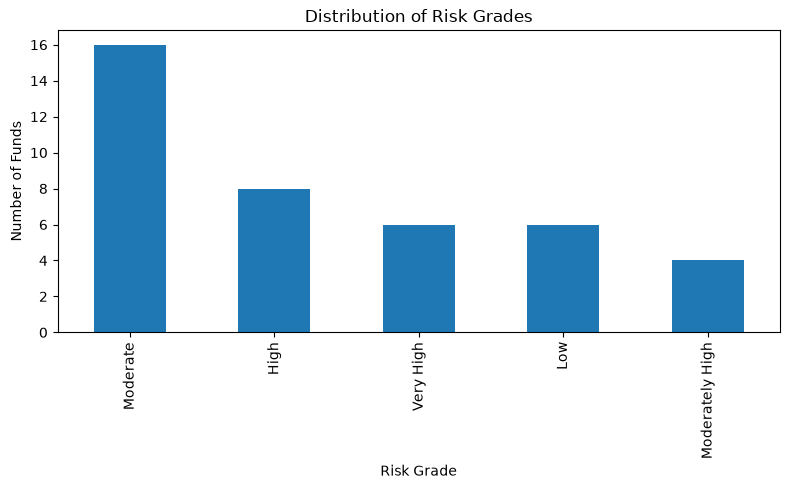

In [21]:
risk_counts = scheme_performance["risk_grade"].value_counts()

plt.figure(figsize=(8,5))

risk_counts.plot(kind="bar")

plt.title("Distribution of Risk Grades")

plt.xlabel("Risk Grade")

plt.ylabel("Number of Funds")

plt.tight_layout()

plt.show()

## Insight

Most mutual fund schemes fall into the Moderate, High, or Very High risk categories, reflecting the growth-oriented nature of equity investments.